# Feature Selection

##  Learning Outcomes

After this video, you'll be able to:

<ul>
    <li>Evaluate feature importance systematically</li>
    <li>Remove redundant and low-impact features</li>
    <li>Apply feature selection techniques</li>
    <li>Optimize feature sets within AWS free tier constraints</li>
</ul>


## Initial Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('insightlysoft_dataset.csv')
X = df.drop(['churned', 'account_id'], axis=1)
y = df['churned']

## Correlation Analysis

In [3]:
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = X[numeric_cols].corr()

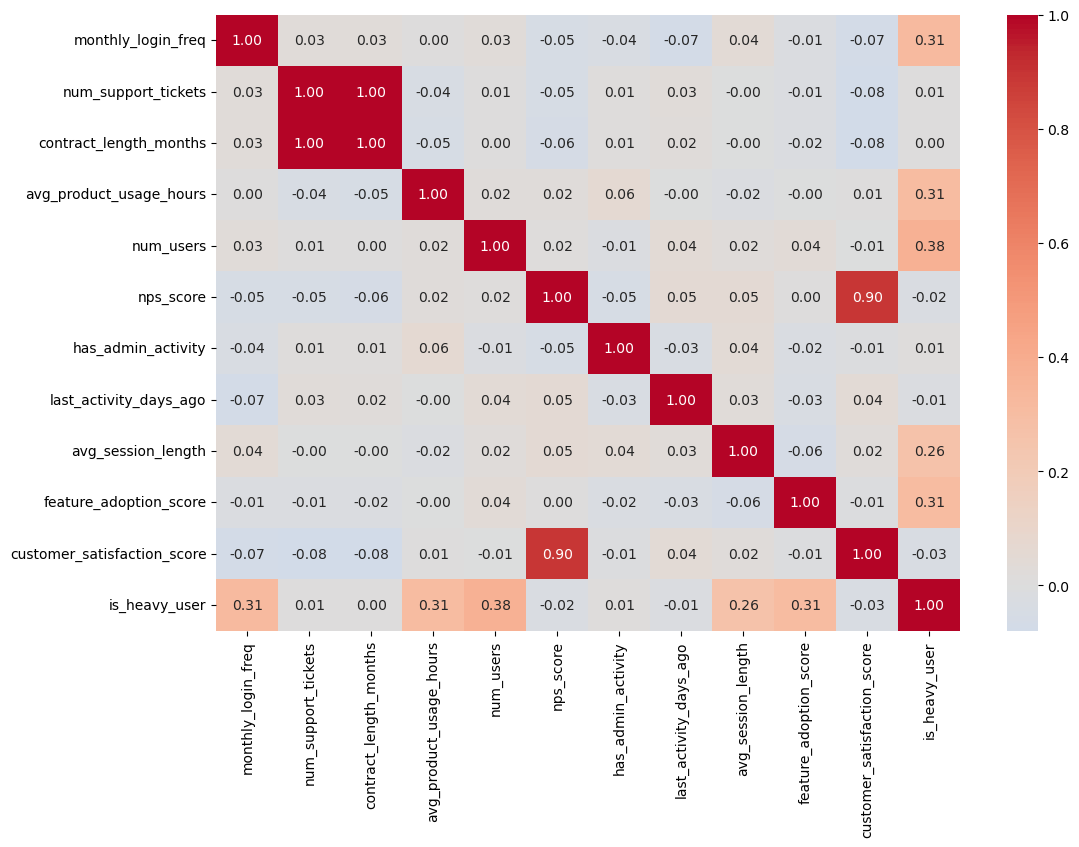

In [4]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, 
            cmap='coolwarm', 
            center=0,
            annot=True,
            fmt='.2f');

## Statistical Feature Selection

In [5]:
selector = SelectKBest(score_func=mutual_info_classif, k=10)
X_selected = selector.fit_transform(X[numeric_cols], y)

In [6]:
feature_scores = pd.DataFrame({
    'Feature': numeric_cols,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

feature_scores.head()

,Feature,Score
7,last_activity_days_ago,0.265911
3,avg_product_usage_hours,0.103587
5,nps_score,0.023736
8,avg_session_length,0.023229
2,contract_length_months,0.017810


## Model-Based Feature Importance

In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X[numeric_cols], y)

rf_importances = pd.DataFrame({
    'Feature': numeric_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

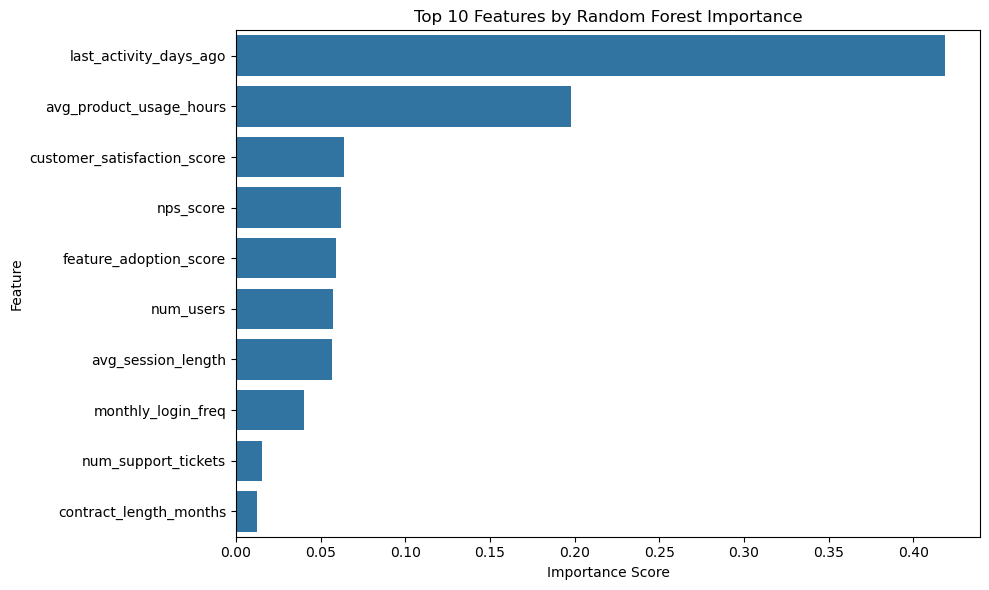

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importances.head(10), x='Importance', y='Feature')
plt.title('Top 10 Features by Random Forest Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Recap


In this video, we covered:

- Analyzing feature correlations

- Applying statistical feature selection 

- Using Random Forest importance 

- Creating a final optimized feature set

